## **How to Combine Elbow and Silhouette Method**
Step 1: Use the Elbow Method to Narrow Down k <br>
• Run K-Means for a range of clusters (say k = 2 to 10). <br>
• Plot SSE (inertia) vs. k. <br>
• Look for the elbow point where improvement slows. <br>
• Usually you’ll see 2–3 candidate k values near the elbow. <br>
Example: The elbow looks around k = 3 or 4. <br>
 
Step 2: Use Silhouette Method on Candidate k Values <br>
• Now only check silhouette scores for those candidate values (instead of all possible k). <br>
• The silhouette score gives you a numerical, objective measure of how well-separated the 
clusters are. <br>
• Choose the k with the highest silhouette score.<br><br> 
 
  Example <br>
Suppose we tested k = 2 to 10. <br>
• Elbow Method Plot shows the elbow around k = 3 or 4. <br>
• Silhouette Scores: <br>
o k = 3 → 0.57 <br>
o k = 4 → 0.64 <br>
So we pick k = 4 (best silhouette score among elbow candidates) <br>

### **How This Works in Practice** 
1. Elbow Method: 
o You’ll see SSE dropping sharply until around k=5, then the improvement slows → 
suggests 5 clusters. 
2. Silhouette Method: 
o Prints values like:<br>
▪ k=4 → 0.55 <br>
▪ k=5 → 0.62    (highest) <br>
▪ k=6 → 0.48 <br>
o So k=5 is chosen. <br>
 
   Result: You discover there are 5 customer segments (e.g., low income–low spenders, high income–
high spenders, etc.). 

In [3]:
#data\Mall_Customers.csv

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Step 1: Load dataset (Mall_Customers.csv)
# Dataset has columns: CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)
df = pd.read_csv("data\Mall_Customers.csv")

# Use only income and spending score for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Elbow Method
print("Elbow Method (SSE values):")
sse = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    sse[k] = kmeans.inertia_
    print(f"k={k}, SSE={sse[k]:.2f}")

# Step 3: Silhouette Method
print("\nSilhouette Method (scores):")
sil_scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    sil_scores[k] = score
    print(f"k={k}, Silhouette Score={score:.3f}")

# Step 4: Combine Insights
# Suppose elbow suggests 4–6 clusters, now compare their silhouette scores
candidates = [4, 5, 6]
print("\nComparing Elbow candidates with Silhouette:")
for k in candidates:
    print(f"k={k}, SSE={sse[k]:.2f}, Silhouette={sil_scores[k]:.3f}")

best_k = max(candidates, key=lambda k: sil_scores[k])
print(f"\n✅ Final chosen number of clusters = {best_k}")


Elbow Method (SSE values):
k=2, SSE=273.67
k=3, SSE=157.70
k=4, SSE=109.23
k=5, SSE=65.57
k=6, SSE=60.13
k=7, SSE=49.67


c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:14

k=8, SSE=37.32
k=9, SSE=32.50
k=10, SSE=30.06

Silhouette Method (scores):
k=2, Silhouette Score=0.397
k=3, Silhouette Score=0.467
k=4, Silhouette Score=0.494
k=5, Silhouette Score=0.555
k=6, Silhouette Score=0.514
k=7, Silhouette Score=0.502
k=8, Silhouette Score=0.455


c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:14

k=9, Silhouette Score=0.457
k=10, Silhouette Score=0.445

Comparing Elbow candidates with Silhouette:
k=4, SSE=109.23, Silhouette=0.494
k=5, SSE=65.57, Silhouette=0.555
k=6, SSE=60.13, Silhouette=0.514

✅ Final chosen number of clusters = 5


c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:14

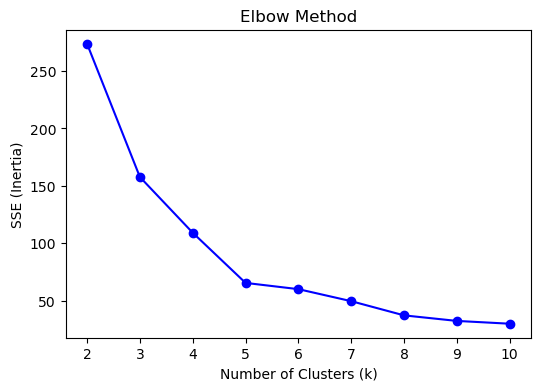

c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:14

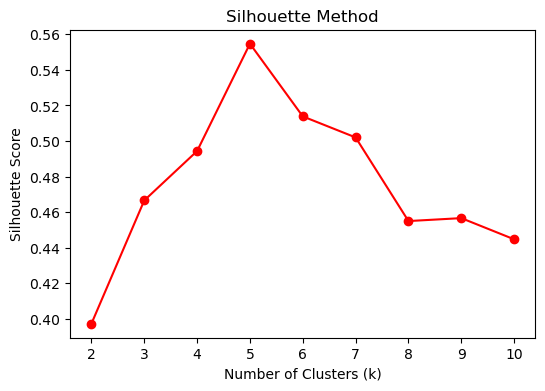

c:\Users\mdash\anaconda3\envs\Tensorflow\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


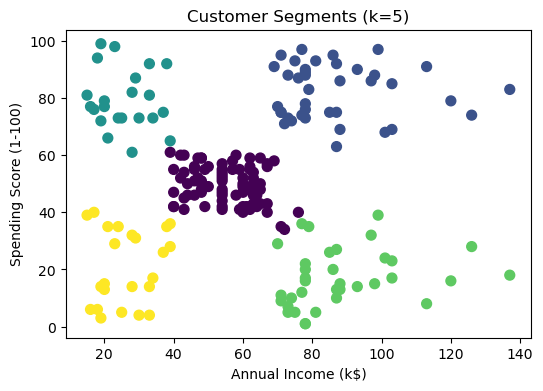

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Step 1: Load dataset (Mall_Customers.csv)
df = pd.read_csv("data\Mall_Customers.csv")

# Use only Annual Income & Spending Score for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Elbow Method
sse = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, sse, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

# Step 3: Silhouette Method
sil_scores = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

# Step 4: Final Visualization of Clusters (example with best k=5)
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42).fit(X_scaled)
df['Cluster'] = kmeans.labels_

plt.figure(figsize=(6,4))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Cluster'], cmap='viridis', s=50)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"Customer Segments (k={best_k})")
plt.show()
